Libraries

In [186]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator

PDE and FD reference Parameters


In [187]:
# ── PDE ────────────────────────────────────────────────────────
alpha = 0.05

# ── FD reference grid ──────────────────────────────────────────
nx    = 20
T     = 0.5
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

Analytical diffusion solution


In [188]:
def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

FD For diffusion

In [189]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp

__init__

In [190]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every

    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()

    def find_neighbours(self, x_star, t_star, n_neighbours=5):
        self._ensure()
        xn  = x_star / dx
        tn  = t_star / dt
        bn  = 2.0
        while True:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb   = [
                self._pts[i] for i in idxs
                if 0 < (t_star - self._pts[i][1]) <= bn * dt
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]
            bn = min(bn * 1.5, 15.0)
            if bn >= 15.0:
                return None

    def __len__(self):
        return len(self._pts)

GFDM Solver


In [191]:
def solve_weights(dx_i, dt_i):
    """
    Pure diffusion constraint matrix.
    Returns (w, success).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, False

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if np.max(np.abs(w)) > 3.0 / len(dx_i):
        return None, False
    if np.min(w) < -1.0:
        return None, False

    return w, True

PDEEnvironment

In [192]:
class PDEEnvironment:


#-----------------------------------first part-----------------------------------------
    def __init__(self):

        # ── PDE constants────────────────────────────────────────────────────────
        self.alpha = alpha

        # ── Grid variables───────────────────────────────────────────────────────
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T = T
        # ── Target point (z*) ─────────────────────────────────────────────────────
        self.x_star = 0.5
        self.t_star = 10 * dt

        # ── RL parameters _to be adjusted──────────────────────────────────────────────
        self.N      = 5
        self.K_max  = 1000
        self.lam    = 0.001
        self.Kx     = 4
        self.Kt     = 4

        # ── GFDM how many neighbours───────────────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ──────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions (where are the initial conditions?) ────────────────────────────────────
        self.walker_init_x = [0.3, 0.4, 0.5, 0.6, 0.7]

        # ── FD reference built once ────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ───────────────────────
        self.visited    = None
        self.walker_x   = None
        self.walker_t   = None
        self.walker_u   = None
        self.step_count = 0



#--------------------------------------------------------------------------------
#second part
    def reset(self):

        # ── Fresh visited list (where are the neighbours?) ──────────────────────────────────────
        self.visited = VisitedSet()

        # ── Seed with IC (we start with the intiial walker positions) ────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        # ── Seed with BCs ──────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        # ── Place walkers at t=0 ───────────────────────────────────────
        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_init_x])

        # ── Reset step counter ─────────────────────────────────────────
        self.step_count = 0

        return self._build_state()
    #Build state vector
    def _build_state(self):
        state = []
        for i in range(self.N):
            state.append(self.walker_x[i])
            state.append(self.walker_t[i])
            state.append(self.walker_u[i])
        state.append(self.x_star)
        state.append(self.t_star)
        return np.array(state, dtype=float)
    def _decode_action(self, action_idx):
        # action_idx is an integer in [0, 44]
        # dx ∈ {-4,-3,-2,-1,0,1,2,3,4} · dx  → 9 options
        # dt ∈ {0,1,2,3,4} · dt               → 5 options
        # layout: action_idx = dx_idx * 5 + dt_idx

        dx_idx = action_idx // 5
        dt_idx = action_idx % 5

        dx = (dx_idx - self.Kx) * self.dx
        dt = dt_idx * self.dt

        return dx, dt
    
    ## check if the new point collides with any visited point (within eps_x and eps_t)
    def _check_collision(self, x, t):
        for (xv, tv, _) in self.visited._pts:
            if abs(xv - x) < self.eps_x and abs(tv - t) < self.eps_t:
                return True
        return False
    
    def _gfdm_solve(self, x_star, t_star):

        # ── Find neighbours ────────────────────────────────────────────
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False

        nb    = np.array(nb)
        dx_i  = nb[:, 0] - x_star
        dt_i  = nb[:, 1] - t_star

        # ── Two-sided spatial coverage check ──────────────────────────
        if not (np.min(dx_i) < 0 < np.max(dx_i)):
            return None, False

        # ── Solve weights ──────────────────────────────────────────────
        w, success = solve_weights(dx_i, dt_i)
        if not success:
            return None, False

        # ── Predict ────────────────────────────────────────────────────
        u_hat = float(w @ nb[:, 2])

        return u_hat, True
    

    """ 1. Increment step counter

        2. For each walker i:
            a. _decode_action(actions[i])        → (dx, dt)
            b. propose new point (x + dx, t + dt)
            c. check domain bounds               → reject if out of [0,1] × [0,T]
            d. _check_collision()                → reject if already visited
            e. _gfdm_solve()                     → reject if GFDM fails
            f. if accepted:
                    update walker_x[i], walker_t[i], walker_u[i]
                    add point to visited list
                    check if walker reached z*      → if yes, done=True

        3. After all walkers processed:
        if done:
            compute terminal reward
        elif step_count >= K_max:
            apply timeout penalty, done=True
        else:
            reward = 0

        4. _build_state()
        5. return state, reward, done, info"""

    #----------------------------------------------------------------------------------------------------------------------
    # step function: takes an action index, updates the environment, and returns (new_state, reward, done)
    def step(self, actions):

        self.step_count += 1
        done    = False
        reward  = 0.0
        info    = {'accepted': [], 'rejected': [], 'reached': False}

        # ── Process each walker ────────────────────────────────────────
        for i in range(self.N):

            dx, dt = self._decode_action(actions[i])

            x_new = self.walker_x[i] + dx
            t_new = self.walker_t[i] + dt

            # ── Domain bounds ──────────────────────────────────────────
            if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
                info['rejected'].append((i, 'bounds'))
                continue

            # ── Collision ──────────────────────────────────────────────
            if self._check_collision(x_new, t_new):
                info['rejected'].append((i, 'collision'))
                continue

            # ── GFDM solve ─────────────────────────────────────────────
            u_hat, success = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'].append((i, 'gfdm'))
                continue

            # ── Accept ─────────────────────────────────────────────────
            self.visited.add(x_new, t_new, u_hat)
            self.walker_x[i] = x_new
            self.walker_t[i] = t_new
            self.walker_u[i] = u_hat
            info['accepted'].append(i)

            # ── Check termination ──────────────────────────────────────
            if (abs(x_new - self.x_star) < self.eps_x and
                abs(t_new - self.t_star) < self.eps_t):
                done = True
                info['reached'] = True

        # ── Reward ─────────────────────────────────────────────────────
        if done:
            u_pred       = self._gfdm_solve(self.x_star, self.t_star)[0]
            u_ref        = u_true(self.x_star, self.t_star)
            reward       = -abs(u_pred - u_ref) - self.lam * self.step_count
            info['u_pred'] = u_pred
            info['u_ref']  = u_ref
            info['error']  = abs(u_pred - u_ref)

        elif self.step_count >= self.K_max:
            done   = True
            reward = -1.0
            info['timeout'] = True

        state = self._build_state()
        return state, reward, done, info

In [193]:
env   = PDEEnvironment()
state = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    actions = [np.random.randint(45) for _ in range(env.N)]
    state, reward, done, info = env.step(actions)

    total_accepted += len(info['accepted'])
    for (_, reason) in info['rejected']:
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    for i in info['accepted']:
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Rejections:     {total_rejected}")
print(f"Walker t positions: {env.walker_t}")

Steps:          1000
Reward:         -1.000000
Reached:        False
Timeout:        True
Total accepted: 32
Rejections:     {'bounds': 731, 'gfdm': 3704, 'collision': 533}
Walker t positions: [0.11904762 0.14285714 0.0952381  0.14285714 0.11904762]


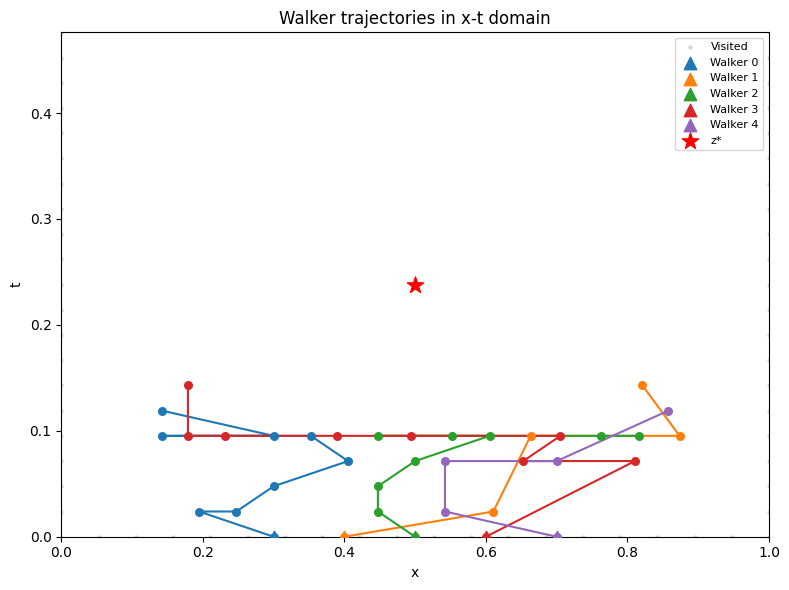

In [194]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', color=colors[i], linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [195]:
import stable_baselines3
print(stable_baselines3.__version__)

2.7.0


In [196]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNetwork(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)

In [197]:
policy    = PolicyNetwork(state_dim=17, action_dim=45)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

In [198]:
def run_episode(env, policy, t_star):
    env.t_star = t_star
    state      = env.reset()
    done       = False

    log_probs  = []
    reward     = 0.0

    while not done:
        # ── Convert state to tensor ────────────────────────────────
        state_tensor = torch.FloatTensor(state)

        # ── Get action probabilities ───────────────────────────────
        probs        = policy(state_tensor)

        # ── Sample one action per walker ───────────────────────────
        actions      = []
        step_log_prob = 0.0
        for i in range(env.N):
            dist     = torch.distributions.Categorical(probs)
            action   = dist.sample()
            actions.append(action.item())
            step_log_prob += dist.log_prob(action)

        log_probs.append(step_log_prob)

        state, reward, done, info = env.step(actions)

    return log_probs, reward, info.get('reached', False)


def update_policy(optimizer, log_probs, reward):
    # ── REINFORCE loss ─────────────────────────────────────────────
    loss = 0.0
    for lp in log_probs:
        loss += -lp * reward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
t_star_schedule = [3, 6, 10, 15, 20]
advance_window  = 50      # look at last 50 episodes
advance_thresh  = 0.7     # 70% success rate to advance

env      = PDEEnvironment()
policy   = PolicyNetwork(state_dim=17, action_dim=45)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

stage        = 0
episode      = 0
reached_log  = []

while stage < len(t_star_schedule):
    t_star   = t_star_schedule[stage] * dt
    log_probs, reward, reached = run_episode(env, policy, t_star)

    update_policy(optimizer, log_probs, reward)

    reached_log.append(reached)
    episode    += 1

    # ── Logging ────────────────────────────────────────────────────
    if episode % 50 == 0:
        recent      = reached_log[-advance_window:]
        success_rate = sum(recent) / len(recent)
        print(f"Stage {stage+1} | t*={t_star:.4f} | "
              f"Episode {episode} | "
              f"Success rate: {success_rate:.2f}")

    # ── Curriculum advancement ─────────────────────────────────────
    if len(reached_log) >= advance_window:
        recent       = reached_log[-advance_window:]
        success_rate = sum(recent) / len(recent)
        if success_rate >= advance_thresh:
            print(f"\n→ Advancing to stage {stage+2}\n")
            stage      += 1
            reached_log = []